In [1]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import seaborn as sns

from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE   = 224
BATCH_SIZE = 32
THRESHOLD  = 0.5



Matplotlib is building the font cache; this may take a moment.


In [2]:
base_dir = "cell_images"
output_dir = "dataset"
classes    = ["Parasitized", "Uninfected"]

for cls in classes:
    os.makedirs(f"{output_dir}/train/{cls}", exist_ok=True)
    os.makedirs(f"{output_dir}/val/{cls}",   exist_ok=True)
    os.makedirs(f"{output_dir}/test/{cls}",  exist_ok=True)

for cls in classes:
    all_files = [
        f for f in os.listdir(f"{base_dir}/{cls}")
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    random.shuffle(all_files)
    train_end = int(0.70 * len(all_files))
    val_end   = int(0.85 * len(all_files))

    for i, file in enumerate(all_files):
        src = f"{base_dir}/{cls}/{file}"
        if i < train_end:
            dst = f"{output_dir}/train/{cls}/{file}"
        elif i < val_end:
            dst = f"{output_dir}/val/{cls}/{file}"
        else:
            dst = f"{output_dir}/test/{cls}/{file}"
        shutil.copy(src, dst)
    print(f"{cls} split done")



Parasitized split done
Uninfected split done



CLASS DISTRIBUTION CHECK
  Train — Parasitized    : 9645 images
  Train — Uninfected     : 9645 images

  Val   — Parasitized    : 2067 images
  Val   — Uninfected     : 2067 images

  Test  — Parasitized    : 2067 images
  Test  — Uninfected     : 2067 images

  Total train images : 19290
  Imbalance ratio    : 1.00:1
Dataset is BALANCED — no class weights needed


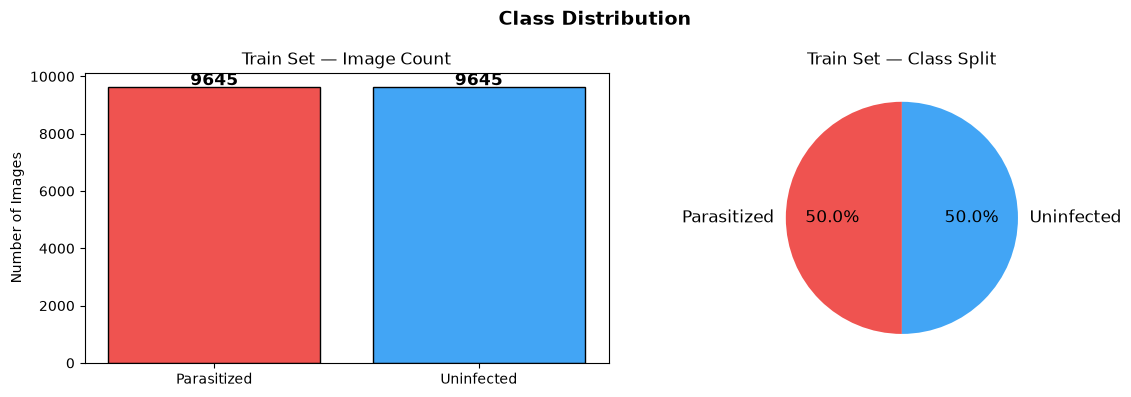


 Computed Class Weights:
   Parasitized : 1.0000
   Uninfected  : 1.0000


In [3]:
from sklearn.utils.class_weight import compute_class_weight

print("\nCLASS DISTRIBUTION CHECK")
print("="*45)

class_counts = {}
for cls in classes:
    count = len([
        f for f in os.listdir(f"{output_dir}/train/{cls}")
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    class_counts[cls] = count
    print(f"  Train — {cls:15s}: {count} images")

print()
for cls in classes:
    count = len([
        f for f in os.listdir(f"{output_dir}/val/{cls}")
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    print(f"  Val   — {cls:15s}: {count} images")

print()
for cls in classes:
    count = len([
        f for f in os.listdir(f"{output_dir}/test/{cls}")
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    print(f"  Test  — {cls:15s}: {count} images")

total      = sum(class_counts.values())
max_count  = max(class_counts.values())
min_count  = min(class_counts.values())
ratio      = max_count / min_count

print(f"\n  Total train images : {total}")
print(f"  Imbalance ratio    : {ratio:.2f}:1")

if ratio < 1.5:
    print("Dataset is BALANCED — no class weights needed")
else:
    print("Dataset is IMBALANCED — applying class weights")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution", fontsize=14, fontweight='bold')

# Bar chart
axes[0].bar(class_counts.keys(), class_counts.values(),
            color=['#EF5350', '#42A5F5'], edgecolor='black')
axes[0].set_title("Train Set — Image Count")
axes[0].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 50, str(cnt), ha='center',
                 fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            colors=['#EF5350', '#42A5F5'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Train Set — Class Split")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

parasitized_count = class_counts['Parasitized']
uninfected_count  = class_counts['Uninfected']
total_train       = parasitized_count + uninfected_count

# Formula: weight = total / (num_classes * class_count)
weight_parasitized = total_train / (2 * parasitized_count)
weight_uninfected  = total_train / (2 * uninfected_count)

print(f"\n Computed Class Weights:")
print(f"   Parasitized : {weight_parasitized:.4f}")
print(f"   Uninfected  : {weight_uninfected:.4f}")
print("="*45)

MobileNetV2 Model

In [4]:
#DATA GENERATORS

train_gen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    f"{output_dir}/train",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)
val_data = val_gen.flow_from_directory(
    f"{output_dir}/val",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)
test_data = val_gen.flow_from_directory(
    f"{output_dir}/test",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)
print("Class indices:", train_data.class_indices)



Found 19290 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}


In [5]:
# MobileNetV2 MODEL

base_model = tf.keras.applications.MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False

x      = base_model.output
x      = layers.Conv2D(128, (3,3), activation='relu',
                        padding='same', name='last_conv')(x)
x      = layers.GlobalAveragePooling2D()(x)
x      = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,732,801 (14.24 MB)

 Trainable params: 1,474,817 (5.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# TRAIN

class_weight_dict = {}
for cls_name, idx in train_data.class_indices.items():
    if cls_name == 'Parasitized':
        class_weight_dict[idx] = weight_parasitized
    else:
        class_weight_dict[idx] = weight_uninfected

print("Class weight dict:", class_weight_dict)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", save_best_only=True, verbose=1)
]

history = model.fit(
    train_data,
    validation_data = val_data,
    epochs          = 10,
    callbacks       = callbacks,
    class_weight    = class_weight_dict
)

Class weight dict: {0: 1.0, 1: 1.0}
Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.9005 - loss: 0.2591
Epoch 1: val_loss improved from None to 0.21951, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 464s 763ms/step - accuracy: 0.9005 - loss: 0.2591 - val_accuracy: 0.9289 - val_loss: 0.2195
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9274 - loss: 0.2068
Epoch 2: val_loss did not improve from 0.21951
603/603 ━━━━━━━━━━━━━━━━━━━━ 408s 677ms/step - accuracy: 0.9274 - loss: 0.2068 - val_accuracy: 0.9030 - val_loss: 0.2267
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.9290 - loss: 0.1978
Epoch 3: val_loss improved from 0.21951 to 0.19352, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 407s 675ms/step - accuracy: 0.9290 - loss: 0.1978 - val_accuracy: 0.9320 - val_loss: 0.1935
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.9340 - loss: 0.1856
Epoch 4: val_loss did not improve from 0.19352
603/603 ━━━━━━━━━━━━━━━━━━━━ 545s 904ms/step - accuracy: 0.9340 - loss: 0.1856 - val_accuracy: 0.9383 - val_loss: 0.2049
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9340 - loss: 0.1901
Epoch 5: val_loss improved from 0.19352 to 0.18473, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 426s 706ms/step - accuracy: 0.9340 - loss: 0.1901 - val_accuracy: 0.9320 - val_loss: 0.1847
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9339 - loss: 0.1822
Epoch 6: val_loss did not improve from 0.18473
603/603 ━━━━━━━━━━━━━━━━━━━━ 402s 667ms/step - accuracy: 0.9339 - loss: 0.1822 - val_accuracy: 0.9403 - val_loss: 0.1924
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.9359 - loss: 0.1820
Epoch 7: val_loss improved from 0.18473 to 0.17619, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 399s 662ms/step - accuracy: 0.9359 - loss: 0.1820 - val_accuracy: 0.9357 - val_loss: 0.1762
Epoch 8/10
 16/603 ━━━━━━━━━━━━━━━━━━━━ 5:10 529ms/step - accuracy: 0.9375 - loss: 0.1788

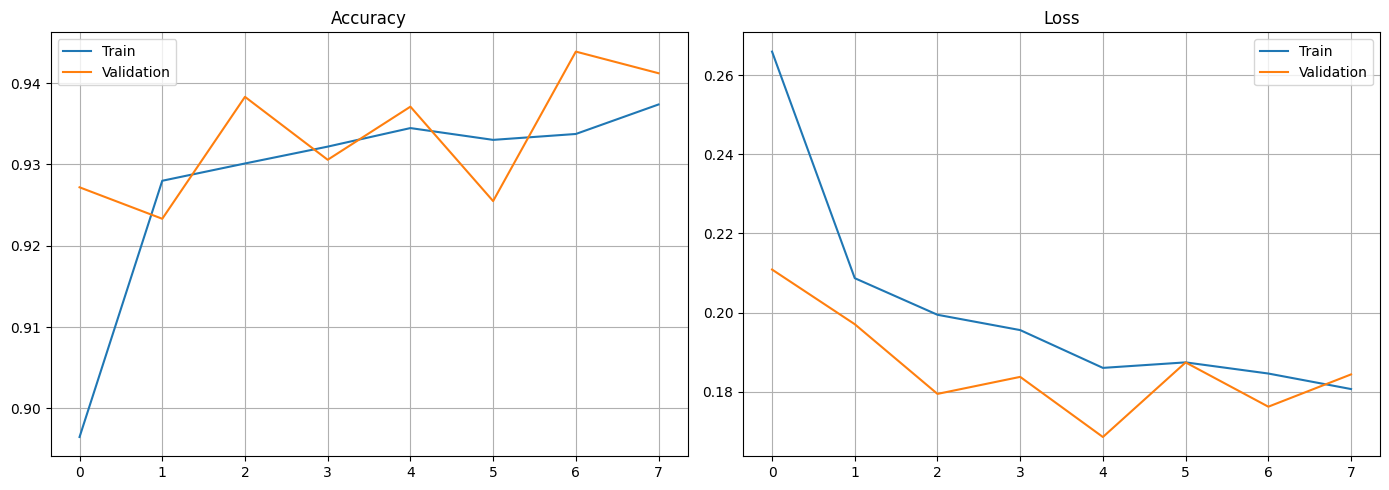

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()



130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9419 - loss: 0.1673

Test Accuracy: 94.19%
130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step

--- Classification Report ---
              precision    recall  f1-score   support

 Parasitized       0.97      0.91      0.94      2067
  Uninfected       0.92      0.97      0.94      2067

    accuracy                           0.94      4134
   macro avg       0.94      0.94      0.94      4134
weighted avg       0.94      0.94      0.94      4134



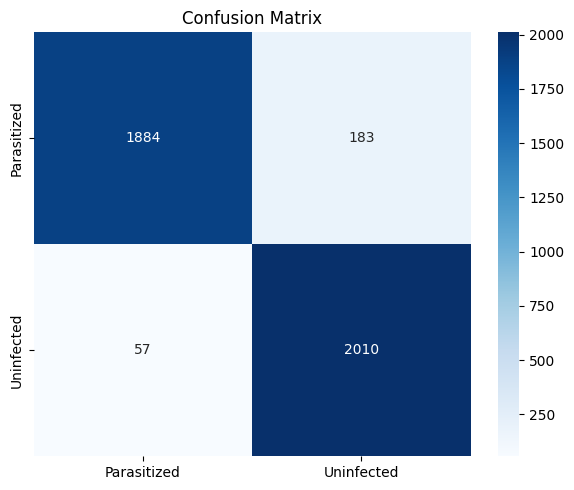

In [ ]:
loss, acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {acc*100:.2f}%")

y_pred = (model.predict(test_data) > THRESHOLD).astype(int).flatten()
y_true = test_data.classes

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred,
      target_names=['Parasitized', 'Uninfected']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Parasitized', 'Uninfected'],
            yticklabels=['Parasitized', 'Uninfected'])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()



CNN Model

In [ ]:
IMG_SIZE_CNN = 128

train_gen_cnn = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1
)
val_gen_cnn = ImageDataGenerator(rescale=1./255)

cnn_train_data = train_gen_cnn.flow_from_directory(
    f"{output_dir}/train",
    target_size = (IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)
cnn_val_data = val_gen_cnn.flow_from_directory(
    f"{output_dir}/val",
    target_size = (IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)
cnn_test_data = val_gen_cnn.flow_from_directory(
    f"{output_dir}/test",
    target_size = (IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)
print("IMG_SIZE:", IMG_SIZE_CNN)
print("Class indices:", cnn_train_data.class_indices)


Found 19290 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
IMG_SIZE: 128
Class indices: {'Parasitized': 0, 'Uninfected': 1}


In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3))

# Block 1 — simple, not doubled
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.3)(x)

# Block 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.3)(x)

# Block 3 — Grad-CAM layer
x = layers.Conv2D(128, (3,3), activation='relu',
                   padding='same', name='cnn_last_conv')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.3)(x)

# Head — smaller Dense layer
x          = layers.GlobalAveragePooling2D()(x)
x          = layers.Dense(128, activation='relu')(x)
x          = layers.Dropout(0.5)(x)
cnn_output = layers.Dense(1, activation='sigmoid')(x)

cnn_model = Model(inputs=inputs, outputs=cnn_output, name='Custom_CNN')

cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_last_conv (Conv2D)          │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_cnn_model.h5",
                    save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        verbose  = 1,
        min_lr   = 1e-7
    )
]

cnn_history = cnn_model.fit(
    cnn_train_data,
    validation_data = cnn_val_data,
    epochs          = 20,
    callbacks       = cnn_callbacks
)


Epoch 1/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7332 - loss: 0.5390
Epoch 1: val_loss improved from None to 0.65040, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 128s 196ms/step - accuracy: 0.8253 - loss: 0.4115 - val_accuracy: 0.6509 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 2/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9279 - loss: 0.2229
Epoch 2: val_loss improved from 0.65040 to 0.20361, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 128s 183ms/step - accuracy: 0.9321 - loss: 0.2113 - val_accuracy: 0.9260 - val_loss: 0.2036 - learning_rate: 0.0010
Epoch 3/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9384 - loss: 0.2008
Epoch 3: val_loss improved from 0.20361 to 0.16572, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 113s 187ms/step - accuracy: 0.9381 - loss: 0.1972 - val_accuracy: 0.9519 - val_loss: 0.1657 - learning_rate: 0.0010
Epoch 4/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9391 - loss: 0.1908
Epoch 4: val_loss did not improve from 0.16572
603/603 ━━━━━━━━━━━━━━━━━━━━ 111s 184ms/step - accuracy: 0.9426 - loss: 0.1842 - val_accuracy: 0.9284 - val_loss: 0.2359 - learning_rate: 0.0010
Epoch 5/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9465 - loss: 0.1723
Epoch 5: val_loss improved from 0.16572 to 0.13324, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 109s 181ms/step - accuracy: 0.9453 - loss: 0.1717 - val_accuracy: 0.9574 - val_loss: 0.1332 - learning_rate: 0.0010
Epoch 6/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9445 - loss: 0.1744
Epoch 6: val_loss did not improve from 0.13324
603/603 ━━━━━━━━━━━━━━━━━━━━ 106s 176ms/step - accuracy: 0.9467 - loss: 0.1658 - val_accuracy: 0.9439 - val_loss: 0.2238 - learning_rate: 0.0010
Epoch 7/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9498 - loss: 0.1611
Epoch 7: val_loss did not improve from 0.13324

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
603/603 ━━━━━━━━━━━━━━━━━━━━ 107s 177ms/step - accuracy: 0.9466 - loss: 0.1644 - val_accuracy: 0.9465 - val_loss: 0.1800 - learning_rate: 0.0010
Epoch 8/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9430 - loss: 0.1650
Epoch 8: val_loss did not improve from 0.13324
603/603 ━━━━━━━━━━━━━━━━━━━━ 1

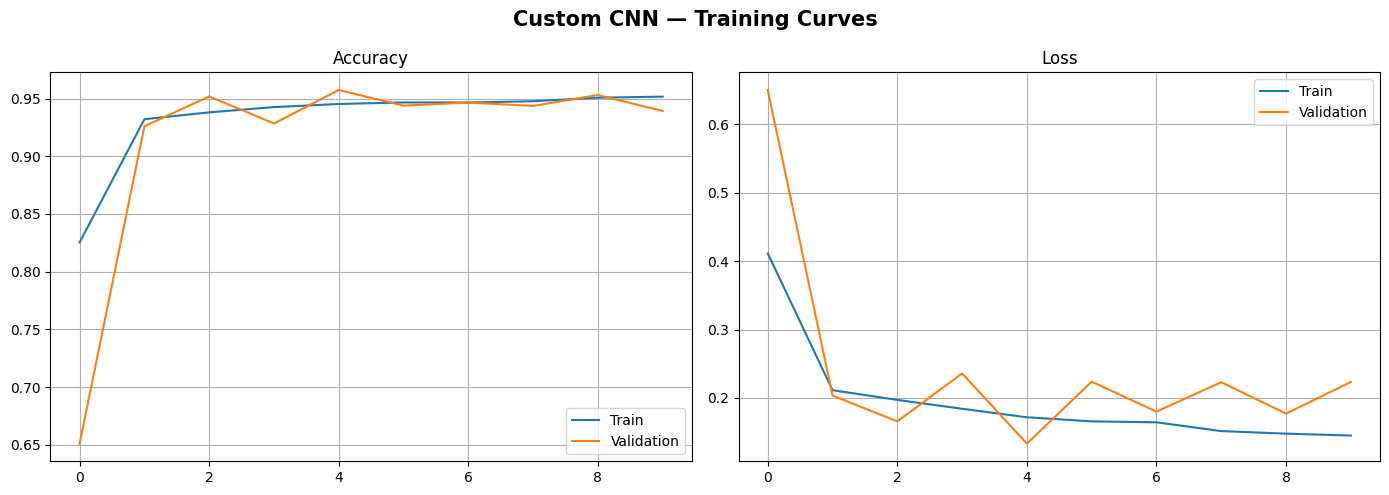

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training Curves', fontsize=15, fontweight='bold')

axes[0].plot(cnn_history.history['accuracy'],     label='Train')
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(cnn_history.history['loss'],     label='Train')
axes[1].plot(cnn_history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9574 - loss: 0.1374

CNN Test Accuracy: 95.74%
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step

--- CNN Classification Report ---
              precision    recall  f1-score   support

 Parasitized       0.96      0.95      0.96      2067
  Uninfected       0.95      0.96      0.96      2067

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



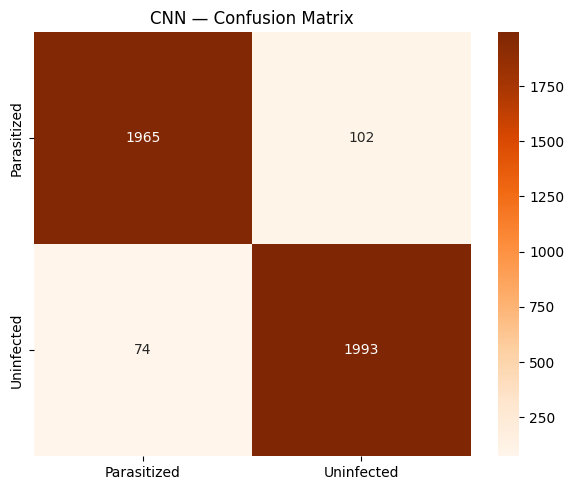

In [ ]:
cnn_test_data.reset()
cnn_loss, cnn_acc = cnn_model.evaluate(cnn_test_data)
print(f"\nCNN Test Accuracy: {cnn_acc*100:.2f}%")

cnn_test_data.reset()
cnn_y_pred = (cnn_model.predict(cnn_test_data) > THRESHOLD).astype(int).flatten()
cnn_y_true = cnn_test_data.classes

print("\n--- CNN Classification Report ---")
print(classification_report(cnn_y_true, cnn_y_pred,
      target_names=['Parasitized', 'Uninfected']))

cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Parasitized', 'Uninfected'],
            yticklabels=['Parasitized', 'Uninfected'])
plt.title("CNN — Confusion Matrix")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150)
plt.show()

The Real Reason CNN Shouldn't Use It
The malaria dataset is almost perfectly balanced (~13,780 Parasitized vs ~13,780 Uninfected), so when you check your class imbalance output it will show:
Dataset is BALANCED — ratio close to 1.0:1
weight_parasitized ≈ 1.0
weight_uninfected  ≈ 1.0

For pretrained models (MobileNetV2, ResNet50) — even weights of ~1.0 cause no harm because they are already stable from ImageNet training.

For CNN from scratch — even a tiny weight difference combined with random initialization caused your validation loss to explode to 7.0, which is what you saw in the graph.

ResNet50 Model

In [ ]:
#   ResNet50 MODEL — MALARIA CLASSIFICATION
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

resnet_train_gen = ImageDataGenerator(
    preprocessing_function = resnet_preprocess,
    rotation_range         = 20,
    zoom_range             = 0.2,
    horizontal_flip        = True,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1
)
resnet_val_gen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

resnet_train_data = resnet_train_gen.flow_from_directory(
    f"{output_dir}/train",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)
resnet_val_data = resnet_val_gen.flow_from_directory(
    f"{output_dir}/val",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary'
)
resnet_test_data = resnet_val_gen.flow_from_directory(
    f"{output_dir}/test",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)
print("ResNet50 Class indices:", resnet_train_data.class_indices)

Found 19290 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
ResNet50 Class indices: {'Parasitized': 0, 'Uninfected': 1}


In [ ]:
resnet_base = tf.keras.applications.ResNet50(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,
    weights     = 'imagenet'
)
resnet_base.trainable = False

x            = resnet_base.output
x            = layers.Conv2D(128, (3,3), activation='relu',
                              padding='same', name='resnet_last_conv')(x)
x            = layers.GlobalAveragePooling2D()(x)
x            = layers.Dropout(0.5)(x)
resnet_output = layers.Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=resnet_base.input,
                     outputs=resnet_output, name='ResNet50_Malaria')

resnet_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "ResNet50_Malaria"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,947,265 (98.98 MB)

 Trainable params: 2,359,553 (9.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_class_weight_dict = {}
for cls_name, idx in resnet_train_data.class_indices.items():
    if cls_name == 'Parasitized':
        resnet_class_weight_dict[idx] = weight_parasitized
    else:
        resnet_class_weight_dict[idx] = weight_uninfected

print("ResNet class weight dict:", resnet_class_weight_dict)

ResNet class weight dict: {0: 1.0, 1: 1.0}


In [ ]:
#Phase1
resnet_callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_resnet_phase1.h5", save_best_only=True, verbose=1)
]

resnet_history1 = resnet_model.fit(
    resnet_train_data,
    validation_data = resnet_val_data,
    epochs          = 10,
    callbacks       = resnet_callbacks_p1,
    class_weight    = resnet_class_weight_dict
)


Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8502 - loss: 0.3662
Epoch 1: val_loss improved from None to 0.19296, saving model to best_resnet_phase1.h5



Epoch 1: finished saving model to best_resnet_phase1.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 293s 462ms/step - accuracy: 0.8973 - loss: 0.2671 - val_accuracy: 0.9277 - val_loss: 0.1930
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9301 - loss: 0.1944
Epoch 2: val_loss improved from 0.19296 to 0.18505, saving model to best_resnet_phase1.h5



Epoch 2: finished saving model to best_resnet_phase1.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 269s 446ms/step - accuracy: 0.9320 - loss: 0.1933 - val_accuracy: 0.9221 - val_loss: 0.1851
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9360 - loss: 0.1813
Epoch 3: val_loss improved from 0.18505 to 0.17245, saving model to best_resnet_phase1.h5



Epoch 3: finished saving model to best_resnet_phase1.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 266s 441ms/step - accuracy: 0.9368 - loss: 0.1801 - val_accuracy: 0.9272 - val_loss: 0.1724
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9351 - loss: 0.1703
Epoch 4: val_loss improved from 0.17245 to 0.15245, saving model to best_resnet_phase1.h5



Epoch 4: finished saving model to best_resnet_phase1.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 266s 442ms/step - accuracy: 0.9371 - loss: 0.1707 - val_accuracy: 0.9429 - val_loss: 0.1525
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9384 - loss: 0.1673
Epoch 5: val_loss did not improve from 0.15245
603/603 ━━━━━━━━━━━━━━━━━━━━ 269s 446ms/step - accuracy: 0.9400 - loss: 0.1691 - val_accuracy: 0.9277 - val_loss: 0.1741
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9445 - loss: 0.1601
Epoch 6: val_loss did not improve from 0.15245
603/603 ━━━━━━━━━━━━━━━━━━━━ 272s 452ms/step - accuracy: 0.9439 - loss: 0.1605 - val_accuracy: 0.9308 - val_loss: 0.1659
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9453 - loss: 0.1535
Epoch 7: val_loss did not improve from 0.15245
603/603 ━━━━━━━━━━━━━━━━━━━━ 275s 457ms/step - accuracy: 0.9438 - loss: 0.1544 - val_accuracy: 0.9194 - val_loss: 0.1872
Epoch 7: early stopping
Restoring model weights from t

In [ ]:
#Phase 2
resnet_base.trainable = True
for layer in resnet_base.layers[:143]:
    layer.trainable = False

resnet_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

resnet_callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_resnet_model.h5", save_best_only=True, verbose=1)
]

resnet_history2 = resnet_model.fit(
    resnet_train_data,
    validation_data = resnet_val_data,
    epochs          = 10,
    callbacks       = resnet_callbacks_p2,
    class_weight    = resnet_class_weight_dict
)

Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9407 - loss: 0.1754
Epoch 1: val_loss improved from None to 0.12829, saving model to best_resnet_model.h5



Epoch 1: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 324s 502ms/step - accuracy: 0.9430 - loss: 0.1661 - val_accuracy: 0.9514 - val_loss: 0.1283
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9503 - loss: 0.1386
Epoch 2: val_loss improved from 0.12829 to 0.12190, saving model to best_resnet_model.h5



Epoch 2: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 289s 479ms/step - accuracy: 0.9514 - loss: 0.1338 - val_accuracy: 0.9519 - val_loss: 0.1219
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9540 - loss: 0.1280
Epoch 3: val_loss improved from 0.12190 to 0.11403, saving model to best_resnet_model.h5



Epoch 3: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 285s 473ms/step - accuracy: 0.9542 - loss: 0.1266 - val_accuracy: 0.9562 - val_loss: 0.1140
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9565 - loss: 0.1163
Epoch 4: val_loss improved from 0.11403 to 0.11045, saving model to best_resnet_model.h5



Epoch 4: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 286s 475ms/step - accuracy: 0.9579 - loss: 0.1161 - val_accuracy: 0.9584 - val_loss: 0.1105
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9611 - loss: 0.1060
Epoch 5: val_loss improved from 0.11045 to 0.10606, saving model to best_resnet_model.h5



Epoch 5: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 292s 484ms/step - accuracy: 0.9601 - loss: 0.1096 - val_accuracy: 0.9623 - val_loss: 0.1061
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9635 - loss: 0.1036
Epoch 6: val_loss improved from 0.10606 to 0.10043, saving model to best_resnet_model.h5



Epoch 6: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 286s 475ms/step - accuracy: 0.9625 - loss: 0.1056 - val_accuracy: 0.9623 - val_loss: 0.1004
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9650 - loss: 0.0968
Epoch 7: val_loss improved from 0.10043 to 0.09992, saving model to best_resnet_model.h5



Epoch 7: finished saving model to best_resnet_model.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 283s 468ms/step - accuracy: 0.9637 - loss: 0.1006 - val_accuracy: 0.9632 - val_loss: 0.0999
Epoch 8/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9681 - loss: 0.0941
Epoch 8: val_loss did not improve from 0.09992
603/603 ━━━━━━━━━━━━━━━━━━━━ 289s 479ms/step - accuracy: 0.9661 - loss: 0.0959 - val_accuracy: 0.9654 - val_loss: 0.1054
Epoch 9/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9674 - loss: 0.0889
Epoch 9: val_loss did not improve from 0.09992
603/603 ━━━━━━━━━━━━━━━━━━━━ 284s 471ms/step - accuracy: 0.9683 - loss: 0.0891 - val_accuracy: 0.9627 - val_loss: 0.1044
Epoch 10/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9699 - loss: 0.0876
Epoch 10: val_loss did not improve from 0.09992
603/603 ━━━━━━━━━━━━━━━━━━━━ 289s 480ms/step - accuracy: 0.9697 - loss: 0.0868 - val_accuracy: 0.9637 - val_loss: 0.1021
Restoring model weights from the end of the best epoc

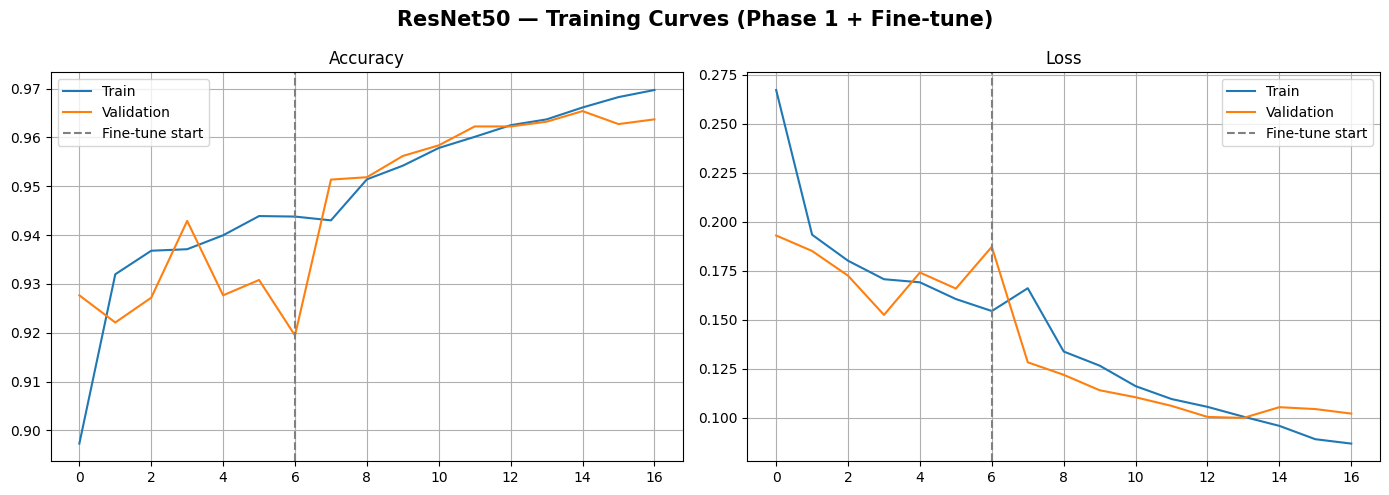

In [ ]:
resnet_acc_plot     = resnet_history1.history['accuracy']     + resnet_history2.history['accuracy']
resnet_val_acc_plot = resnet_history1.history['val_accuracy'] + resnet_history2.history['val_accuracy']
resnet_loss_plot    = resnet_history1.history['loss']         + resnet_history2.history['loss']
resnet_val_loss_plot= resnet_history1.history['val_loss']     + resnet_history2.history['val_loss']
p1_end              = len(resnet_history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 — Training Curves (Phase 1 + Fine-tune)',
             fontsize=15, fontweight='bold')

axes[0].plot(resnet_acc_plot,     label='Train')
axes[0].plot(resnet_val_acc_plot, label='Validation')
axes[0].axvline(p1_end - 1, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(resnet_loss_plot,     label='Train')
axes[1].plot(resnet_val_loss_plot, label='Validation')
axes[1].axvline(p1_end - 1, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("resnet_training_curves.png", dpi=150)
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.9652 - loss: 0.1021

ResNet50 Test Accuracy: 96.52%
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step

--- ResNet50 Classification Report ---
              precision    recall  f1-score   support

 Parasitized       0.98      0.95      0.96      2067
  Uninfected       0.95      0.98      0.97      2067

    accuracy                           0.97      4134
   macro avg       0.97      0.97      0.97      4134
weighted avg       0.97      0.97      0.97      4134



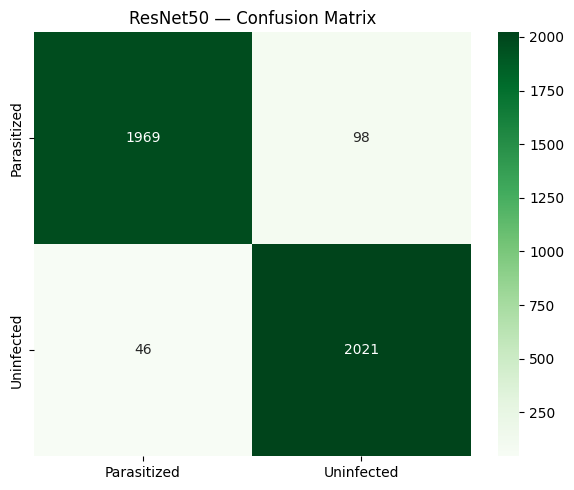

In [ ]:
resnet_loss, resnet_acc = resnet_model.evaluate(resnet_test_data)
print(f"\nResNet50 Test Accuracy: {resnet_acc*100:.2f}%")

resnet_y_pred = (resnet_model.predict(resnet_test_data) > THRESHOLD).astype(int).flatten()
resnet_y_true = resnet_test_data.classes

print("\n--- ResNet50 Classification Report ---")
print(classification_report(resnet_y_true, resnet_y_pred,
      target_names=['Parasitized', 'Uninfected']))

resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Parasitized', 'Uninfected'],
            yticklabels=['Parasitized', 'Uninfected'])
plt.title("ResNet50 — Confusion Matrix")
plt.tight_layout()
plt.savefig("resnet_confusion_matrix.png", dpi=150)
plt.show()

Comparison of All 3 Model


        MODEL COMPARISON SUMMARY
Model                  Test Accuracy      Parameters
-------------------------------------------------------
Custom CNN                    95.74%          110,785
MobileNetV2                   94.19%        3,732,801
ResNet50                      96.52%       25,947,265


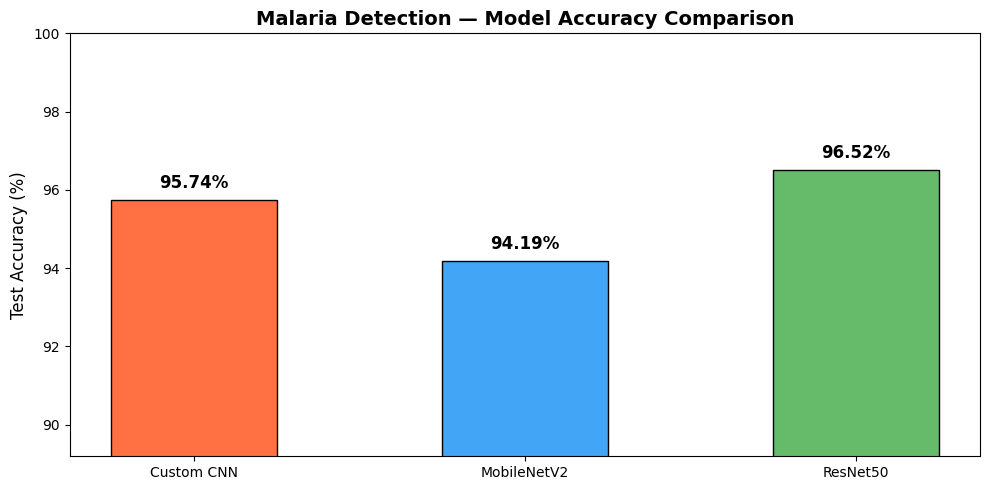

In [ ]:

#COMPARISON — Of All 3 Models

print("\n" + "="*55)
print("        MODEL COMPARISON SUMMARY")
print("="*55)
print(f"{'Model':<20} {'Test Accuracy':>15} {'Parameters':>15}")
print("-"*55)
print(f"{'Custom CNN':<20} {cnn_acc*100:>14.2f}%  {cnn_model.count_params():>15,}")
print(f"{'MobileNetV2':<20} {acc*100:>14.2f}%  {model.count_params():>15,}")
print(f"{'ResNet50':<20} {resnet_acc*100:>14.2f}%  {resnet_model.count_params():>15,}")
print("="*55)

# Bar chart
model_names = ['Custom CNN', 'MobileNetV2', 'ResNet50']
accuracies  = [cnn_acc*100, acc*100, resnet_acc*100]
colors      = ['#FF7043', '#42A5F5', '#66BB6A']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylim(min(accuracies) - 5, 100)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Malaria Detection — Model Accuracy Comparison",
          fontsize=14, fontweight='bold')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.2f}%", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

In [ ]:
all_models = {
    'Custom CNN'  : (cnn_model,      cnn_acc),
    'MobileNetV2' : (model,          acc),
    'ResNet50'    : (resnet_model,   resnet_acc),
}

best_name  = max(all_models, key=lambda k: all_models[k][1])
best_model = all_models[best_name][0]
best_acc   = all_models[best_name][1]

print("="*50)
print(f"  Best Model    : {best_name}")
print(f"  Test Accuracy : {best_acc*100:.2f}%")
print("="*50)
print("\nAll model accuracies:")
for name, (m, a) in all_models.items():
    marker = " Winner " if name == best_name else ""
    print(f"  {name:<15}: {a*100:.2f}%{marker}")

  Best Model    : ResNet50
  Test Accuracy : 96.52%

All model accuracies:
  Custom CNN     : 95.74%
  MobileNetV2    : 94.19%
  ResNet50       : 96.52% Winner 


Using Grad-CAM layer: resnet_last_conv

   GRAD-CAM [ResNet50]: PARASITIZED SAMPLE


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_377']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


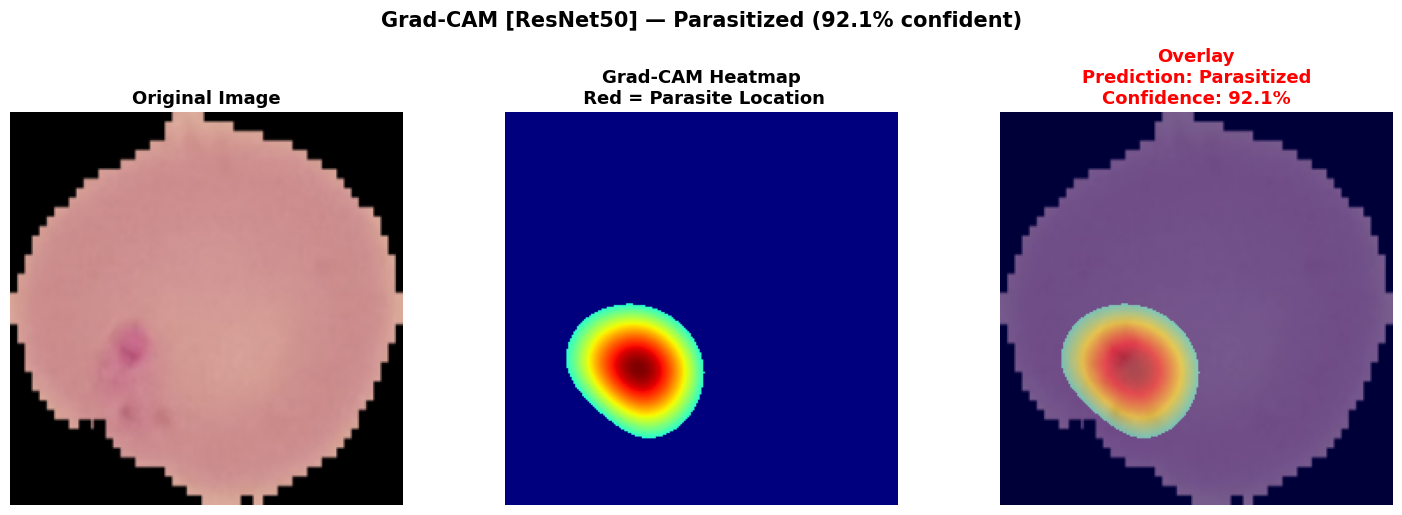

Model used  : ResNet50
Prediction  : Parasitized
Confidence  : 92.1%
Layer used  : resnet_last_conv
----------------------------------------

   GRAD-CAM [ResNet50]: UNINFECTED SAMPLE


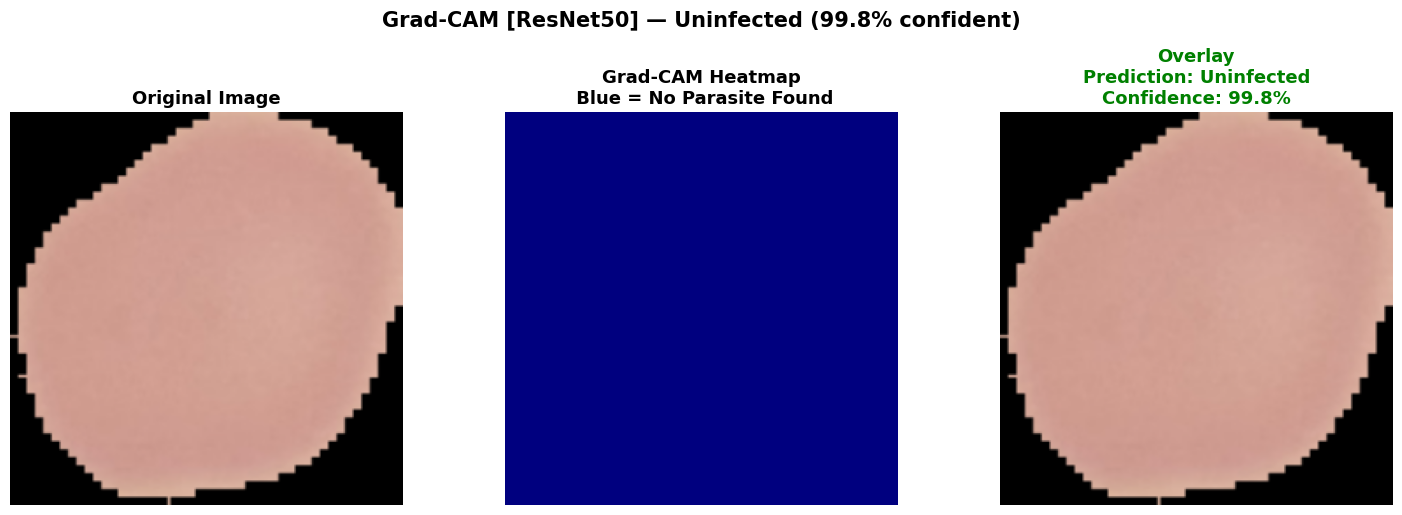

Model used  : ResNet50
Prediction  : Uninfected
Confidence  : 99.8%
Layer used  : resnet_last_conv
----------------------------------------


In [ ]:
# GRAD-CAM

layer_map = {
    'Custom CNN'  : 'cnn_last_conv',
    'MobileNetV2' : 'last_conv',
    'ResNet50'    : 'resnet_last_conv',
}
best_layer = layer_map[best_name]
print(f"Using Grad-CAM layer: {best_layer}")

generator_map = {
    'Custom CNN'  : (cnn_test_data,      1./255,            None),
    'MobileNetV2' : (test_data,          1./255,            None),
    'ResNet50'    : (resnet_test_data,   None,  resnet_preprocess),
}
best_test_data, best_rescale, best_preprocess = generator_map[best_name]

def show_gradcam_best(model, img_path, grad_layer,
                      rescale=None, preprocess_fn=None,
                      threshold=THRESHOLD):

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Cannot read: {img_path}")

    img     = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if preprocess_fn is not None:
        img_arr = np.expand_dims(img_rgb.astype('float32'), axis=0)
        img_arr = preprocess_fn(img_arr)
    else:
        img_arr = np.expand_dims(img_rgb / 255.0, axis=0).astype('float32')

    grad_model = tf.keras.models.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(grad_layer).output, model.output]
    )

    preds_init = model(img_arr, training=False)
    pred_prob  = float(preds_init[0][0])

    class_indices = best_test_data.class_indices
    if class_indices.get('Parasitized', 0) == 0:
        pred_label = "Parasitized" if pred_prob < threshold else "Uninfected"
    else:
        pred_label = "Parasitized" if pred_prob > threshold else "Uninfected"

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_arr, training=False)
        loss = -preds[:, 0] if pred_label == "Parasitized" else preds[:, 0]

    grads        = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    clr        = "red" if pred_label == "Parasitized" else "green"
    confidence = (1 - pred_prob)*100 if pred_label == "Parasitized" else pred_prob*100

    if pred_label == "Uninfected":
        heatmap_norm = np.zeros((IMG_SIZE, IMG_SIZE))
        superimposed = img_rgb.copy()
        htitle       = "Grad-CAM Heatmap\n Blue = No Parasite Found"
    else:
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE),
                                     interpolation=cv2.INTER_CUBIC)
        hmin, hmax      = heatmap_resized.min(), heatmap_resized.max()
        heatmap_norm    = (heatmap_resized - hmin) / (hmax - hmin + 1e-8)
        heatmap_norm[heatmap_norm < 0.4] = 0
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_norm),
                                             cv2.COLORMAP_JET)
        heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        superimposed    = (heatmap_rgb * 0.45 + img_rgb * 0.55).astype("uint8")
        htitle          = "Grad-CAM Heatmap\n Red = Parasite Location"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap_norm, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title(htitle, fontsize=13, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(
        f"Overlay\nPrediction: {pred_label}\nConfidence: {confidence:.1f}%",
        fontsize=13, fontweight='bold', color=clr
    )
    axes[2].axis('off')

    plt.suptitle(
        f"Grad-CAM [{best_name}] — {pred_label} ({confidence:.1f}% confident)",
        fontsize=15, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

    print(f"Model used  : {best_name}")
    print(f"Prediction  : {pred_label}")
    print(f"Confidence  : {confidence:.1f}%")
    print(f"Layer used  : {grad_layer}")
    print("-" * 40)

test_dir = f"{output_dir}/test"

print("\n" + "="*50)
print(f"   GRAD-CAM [{best_name}]: PARASITIZED SAMPLE")
print("="*50)
para_dir = os.path.join(test_dir, "Parasitized")
para_img = os.path.join(para_dir, random.choice([
    f for f in os.listdir(para_dir)
    if f.lower().endswith(('.png','.jpg','.jpeg'))
]))
show_gradcam_best(best_model, para_img, best_layer,
                  best_rescale, best_preprocess)

print("\n" + "="*50)
print(f"   GRAD-CAM [{best_name}]: UNINFECTED SAMPLE")
print("="*50)
uninf_dir = os.path.join(test_dir, "Uninfected")
uninf_img = os.path.join(uninf_dir, random.choice([
    f for f in os.listdir(uninf_dir)
    if f.lower().endswith(('.png','.jpg','.jpeg'))
]))
show_gradcam_best(best_model, uninf_img, best_layer,
                  best_rescale, best_preprocess)

In [ ]:
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D) or 'relu' in layer.name or 'expand' in layer.name:
        try:
            shape = layer.output.shape
            print(f"{layer.name:45s} {str(shape)}")
        except:
            print(f"{layer.name:45s} shape unavailable")

Conv1                                         (None, 112, 112, 32)
Conv1_relu                                    (None, 112, 112, 32)
expanded_conv_depthwise                       (None, 112, 112, 32)
expanded_conv_depthwise_BN                    (None, 112, 112, 32)
expanded_conv_depthwise_relu                  (None, 112, 112, 32)
expanded_conv_project                         (None, 112, 112, 16)
expanded_conv_project_BN                      (None, 112, 112, 16)
block_1_expand                                (None, 112, 112, 96)
block_1_expand_BN                             (None, 112, 112, 96)
block_1_expand_relu                           (None, 112, 112, 96)
block_1_depthwise_relu                        (None, 56, 56, 96)
block_1_project                               (None, 56, 56, 24)
block_2_expand                                (None, 56, 56, 144)
block_2_expand_BN                             (None, 56, 56, 144)
block_2_expand_relu                           (None, 56, 56, 144)
bl

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

model = load_model("best_resnet_model.h5")

IMG_SIZE = 224

def predict_malaria(img):
    img = img.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img).astype("float32")
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    pred = model.predict(img_array, verbose=0)

    if pred.shape[-1] == 1:
        score = pred[0][0]

        if score >= 0.5:
            return {
                "Uninfected": float(score),
                "Parasitized": float(1 - score)
            }
        else:
            return {
                "Parasitized": float(1 - score),
                "Uninfected": float(score)
            }

    else:
        return {
            "Parasitized": float(pred[0][0]),
            "Uninfected": float(pred[0][1])
        }

demo = gr.Interface(
    fn=predict_malaria,
    inputs=gr.Image(type="pil", label="Upload Cell Image"),
    outputs=gr.Label(num_top_classes=2, label="Prediction"),
    title="Malaria Detection using ResNet50",
    description="Upload a blood smear image to classify as Parasitized or Uninfected.",
    theme="soft"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5c2b3af951c1f07119.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
